In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/processed/CVD_cleaned.csv")
df.head()

,General_Health,Checkup,Exercise,Heart_Disease,Skin_Cancer,Other_Cancer,Depression,Diabetes,Arthritis,Sex,Age_Category,Height_(cm),Weight_(kg),BMI,Smoking_History,Alcohol_Consumption,Fruit_Consumption,Green_Vegetables_Consumption,FriedPotato_Consumption
0,Very Good,Within the past year,No,Yes,No,No,No,Yes,No,Female,70-74,165.0,77.11,28.29,No,0.0,30.0,0.0,4.0
1,Very Good,Within the past year,Yes,No,No,No,No,Yes,No,Female,60-64,163.0,88.45,33.47,No,4.0,12.0,3.0,16.0
2,Poor,Within the past year,Yes,Yes,No,No,No,Yes,No,Male,75-79,180.0,93.44,28.73,No,0.0,30.0,30.0,8.0
3,Good,Within the past year,No,No,No,No,No,No,No,Male,80+,191.0,88.45,24.37,Yes,0.0,8.0,4.0,0.0
4,Good,Within the past year,No,No,No,No,Yes,No,Yes,Male,60-64,183.0,154.22,46.11,No,0.0,12.0,12.0,12.0


In [4]:
df["Heart_Disease"].value_counts(normalize=True)

Heart_Disease
No     0.919152
Yes    0.080848
Name: proportion, dtype: float64

### Target Variable Summary

* Heart Disease = 8.08% Yes
* Heart Disease = 91.91% No
* Dataset is heavily imbalanced

## Bivariate Analysis 

In [89]:
def plot_risk_rate(feature, rotation=0, sort=False):
    risk_table =  pd.crosstab(
        df[feature],
        df["Heart_Disease"],
        normalize="index"
        ) * 100
    if sort:
        risk_table = risk_table.sort_values(by="Yes")
    ax = risk_table["Yes"].plot(kind="bar")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%")
    plt.ylabel("Heart Disease Risk (%)")
    plt.xlabel(f"Heart Disease Risk by {feature}")
    plt.xticks(rotation=rotation)
    plt.show()
    return 

### Part 1: Demographics vs Heart Disease

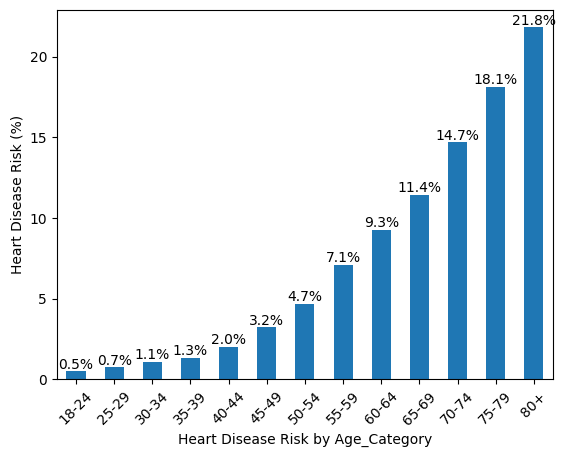

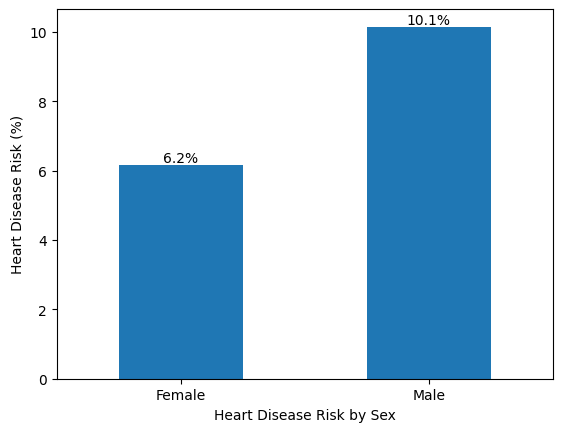

In [90]:
# Age Category/Sex vs Heart Disease
demographics = {"Age_Category": 45, "Sex": 0}
for feature, rotation in demographics.items():
    plot_risk_rate(feature, rotation)

* Heart disease risk increase significantly with age. 
* Older age groups show a much higher percentage of heart disease compared to younger groups.
* Age is likely a strong predictor
* Males show a noticably higher heart disease compared to females, with males at ~10% risk, while females at ~6% risk of heart disease
* This represents nearly a 1.6x increase in risk for males


### Part 2: Body Stats vs Heart Disease

In [92]:
df[["Height_(cm)", "Weight_(kg)", "BMI"]].corr()


,Height_(cm),Weight_(kg),BMI
Height_(cm),1.000000,0.486985,-0.015014
Weight_(kg),0.486985,1.000000,0.858749
BMI,-0.015014,0.858749,1.000000


In [98]:
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0,18.5,25,30,35,40,61],
    labels=["Underweight","Normal","Overweight","Obese 1","Obese 2","Obese 3"]
)

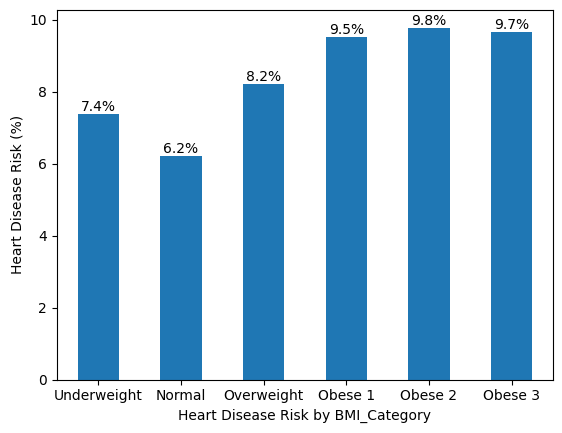

In [99]:
plot_risk_rate("BMI_Category")

### Part 3: Medical History vs Heart Disease

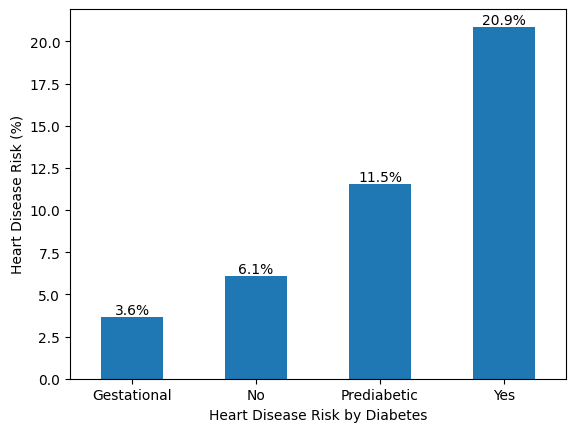

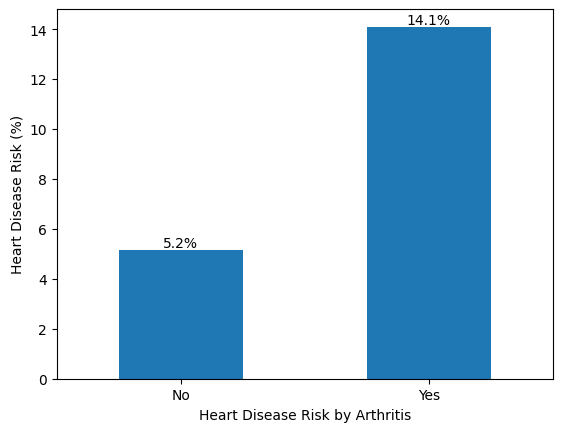

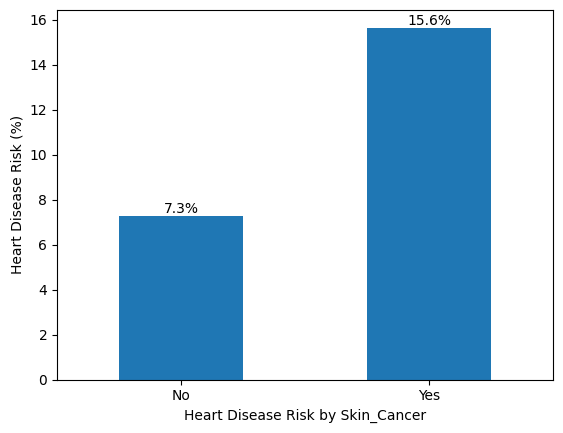

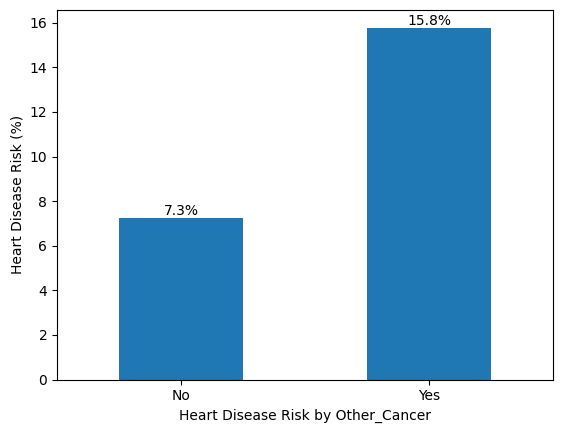

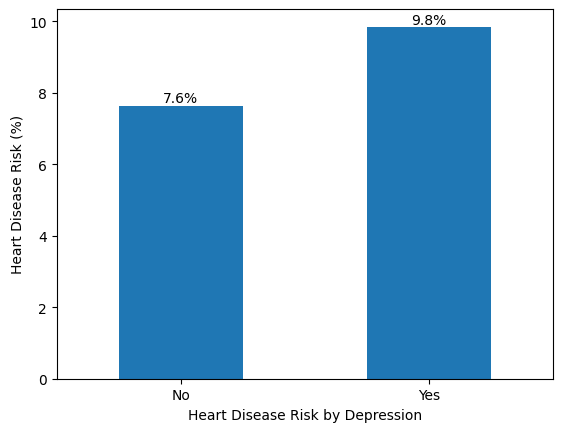

In [100]:
medical_history = ["Diabetes", "Arthritis", "Skin_Cancer", "Other_Cancer", "Depression"]
for cols in medical_history:
    plot_risk_rate(cols)

### Part 3: Lifestyle vs Heart Disease

In [102]:
df["Alcohol_Level"] = pd.cut(df["Alcohol_Consumption"],
                             bins=[-1, 0, 3, 10,31],
                             labels=["Non-Drinkers", "Light (1-3/month)", "Moderate (4-10/month)","Frequent (>10/month)"])

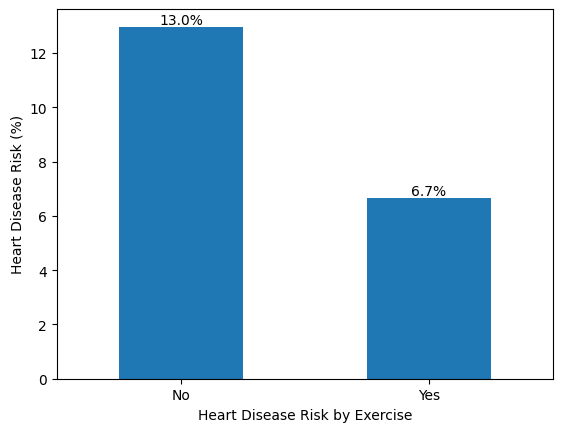

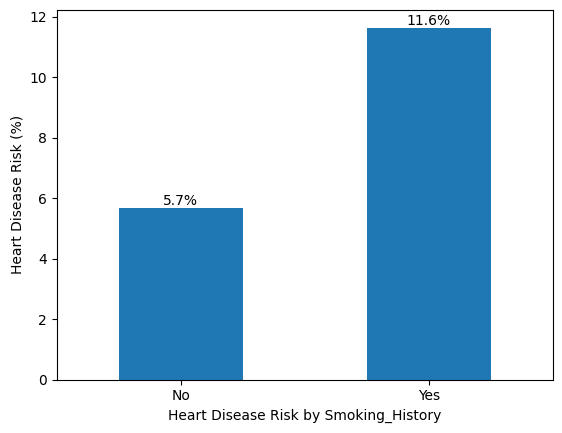

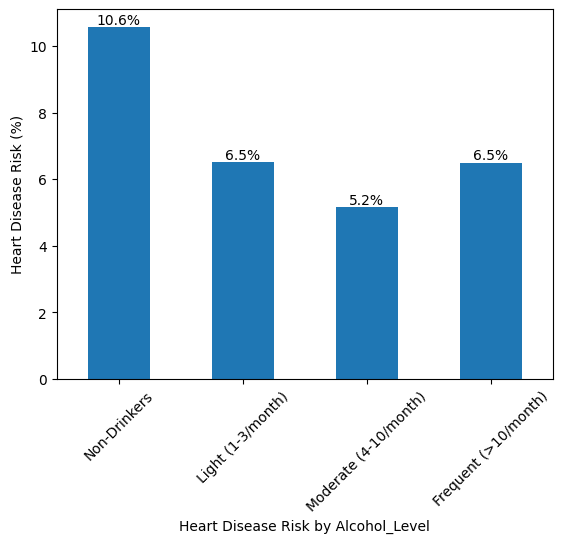

In [105]:
lifestyle = {"Exercise": 0, "Smoking_History": 0,"Alcohol_Level": 45}
for feature, rotation in lifestyle.items():
    plot_risk_rate(feature, rotation)

### Part 4: Diet vs Heart Disease

In [106]:
bins_food = [-1,0,8,15,30,60,130]
labels_food = ["None","Rare (<1/week)", "Weekly", "Almost Daily","Daily","Multiple per day"]
df["Fruit_Level"] = pd.cut(df["Fruit_Consumption"],bins=bins_food, labels=labels_food)
df["Green_Vegetable_Level"] = pd.cut(df["Green_Vegetables_Consumption"],bins=bins_food, labels=labels_food)
df["FriedPotato_Level"] = pd.cut(df["FriedPotato_Consumption"],bins=bins_food,labels=labels_food)

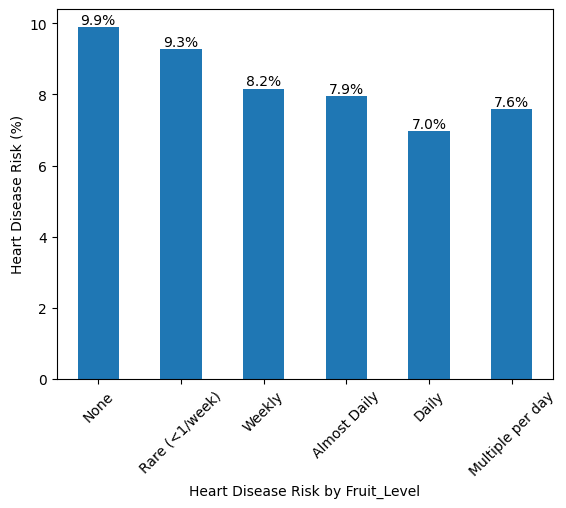

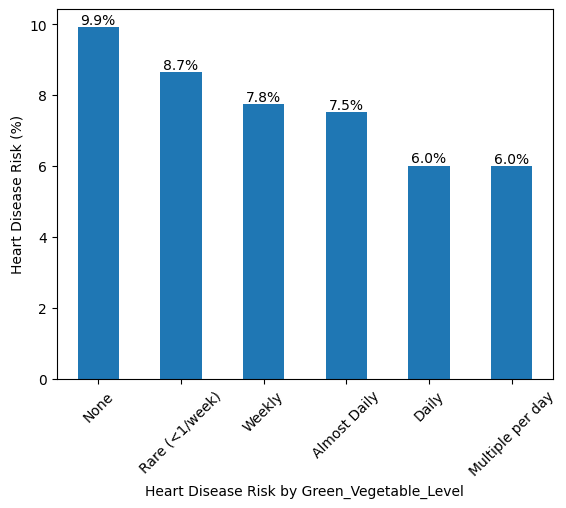

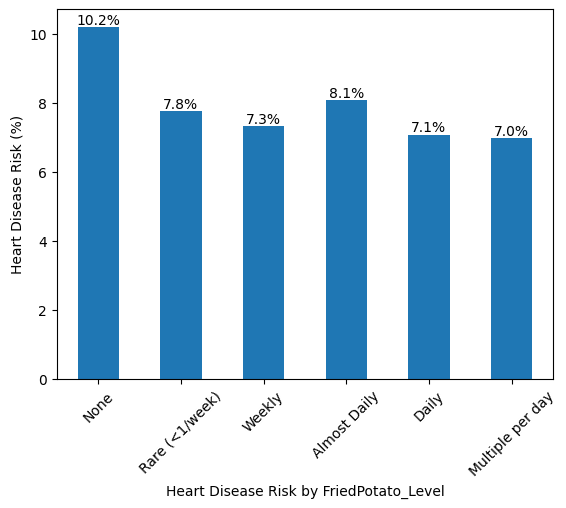

In [109]:
diet = ["Fruit_Level","Green_Vegetable_Level","FriedPotato_Level"]
for feature in diet:
    plot_risk_rate(feature, rotation=45)

### Part 5: Preventive Health vs Heart Disease

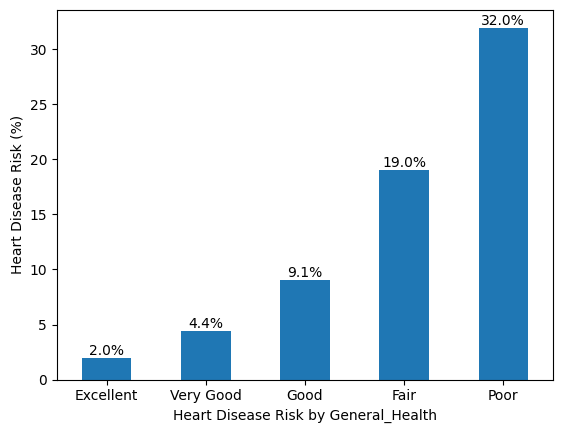

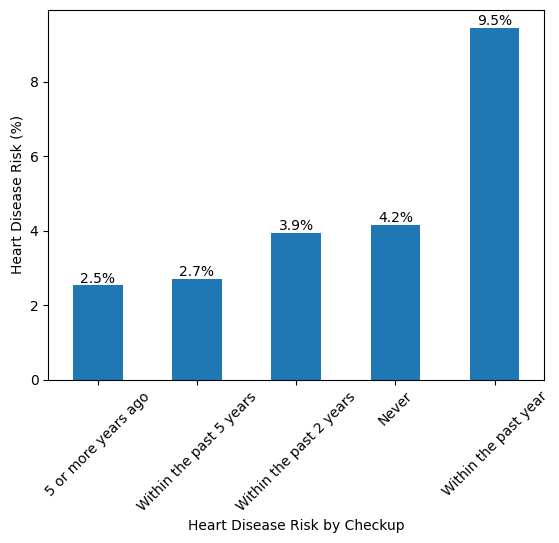

In [115]:
preventive_health = {"General_Health": 0, "Checkup": 45}
for feature, rotation in preventive_health.items():
    plot_risk_rate(feature, rotation,sort=True)